Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)

Load Dataset

In [34]:
df = pd.read_csv('C:/Users/MSIS/Downloads/APS/lab5/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Cleaning & Preprocessing

In [35]:
# Clean TotalCharges safely and fill any missing values with the median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop identifier column
df_model = df.drop(columns=['customerID'])

# Map target variable (Churn) to binary numeric format
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Separate features (X) and target (y)
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# One-hot encode categorical features and convert to float
X_encoded = pd.get_dummies(X, drop_first=True).astype(float)

# Fill any remaining NaNs across features with 0
X_encoded = X_encoded.fillna(0)

print("Features shape:", X_encoded.shape)
print("Any NaNs remaining in X_encoded?", X_encoded.isnull().sum().sum() > 0)

Features shape: (7043, 30)
Any NaNs remaining in X_encoded? False


Train-Test Split

In [36]:
# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())

NaNs in X_train_scaled: 0


Training Logistic Regression Model

In [37]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


Generate Predictions

In [38]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

Calculate Precision, Recall, F1-Score

In [39]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [40]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recalls, precisions)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

Precision : 0.6584
Recall    : 0.5668
F1-Score  : 0.6092
ROC-AUC   : 0.8416
PR-AUC    : 0.6310


In [41]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


--- Confusion Matrix ---
[[925 110]
 [162 212]]


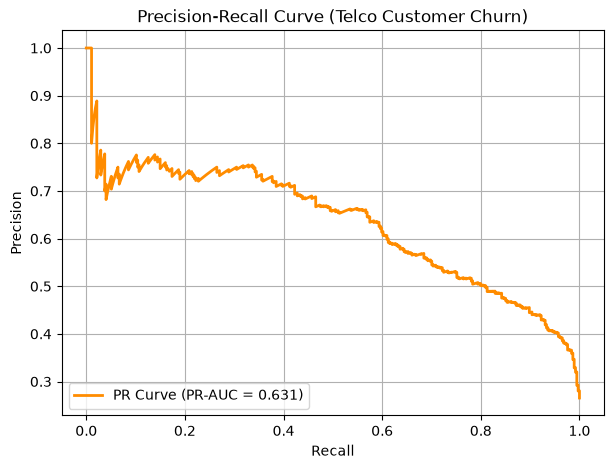

In [42]:
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2, label=f"PR Curve (PR-AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Telco Customer Churn)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()